In [ ]:
%pip install tensorflow keras opencv-python matplotlib numpy ipywidgets

^C
Note: you may need to restart the kernel to use updated packages.


# Handwritten Digit Recognition using CNN

Training Images Shape: (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)


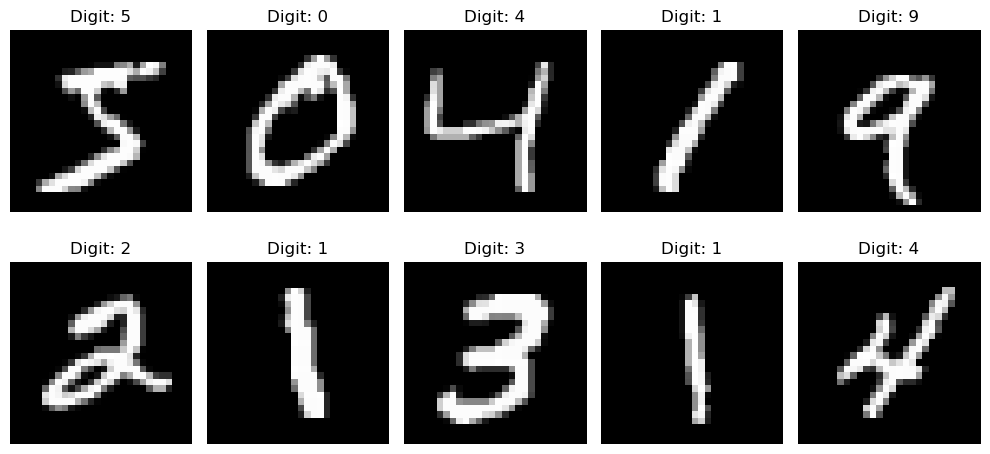

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9577 - loss: 0.1404 - val_accuracy: 0.9811 - val_loss: 0.0547
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9857 - loss: 0.0467 - val_accuracy: 0.9887 - val_loss: 0.0324
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9900 - loss: 0.0319 - val_accuracy: 0.9870 - val_loss: 0.0409
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9922 - loss: 0.0237 - val_accuracy: 0.9865 - val_loss: 0.0427
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9866 - val_loss: 0.0465
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9866 - loss: 0.0465

MODEL PERFORMANCE
Test Accuracy: 0.9865999817848206


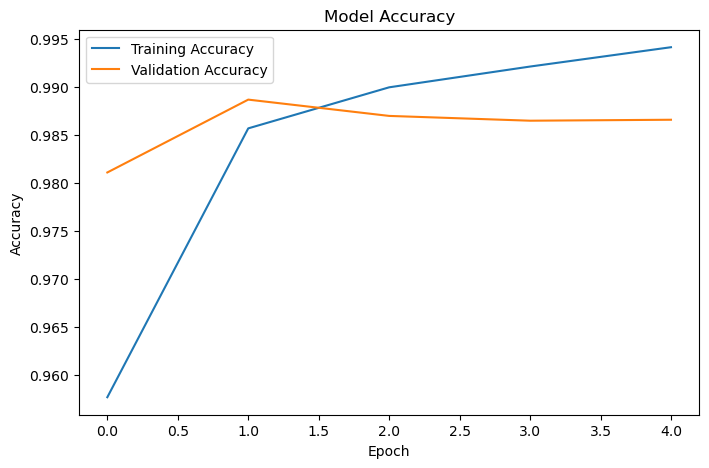


Model Saved Successfully!


In [7]:
# ============================================
# HANDWRITTEN DIGIT RECOGNITION USING CNN
# Advanced Computer Vision Mini Project
# ============================================

# ========= IMPORT LIBRARIES =========

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import numpy as np
import matplotlib.pyplot as plt
import cv2

import ipywidgets as widgets
from IPython.display import display, clear_output

# ========= LOAD MNIST DATASET =========

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

print("Training Images Shape:", train_images.shape)
print("Testing Images Shape :", test_images.shape)

# ========= DISPLAY SAMPLE DIGITS =========

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Digit: {train_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ========= PREPROCESS DATA =========

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape for CNN
train_images = train_images.reshape((60000,28,28,1))
test_images = test_images.reshape((10000,28,28,1))

# ========= BUILD CNN MODEL =========

model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# First Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(64, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

# ========= COMPILE MODEL =========

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ========= TRAIN MODEL =========

history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

# ========= EVALUATE MODEL =========

test_loss, test_acc = model.evaluate(test_images, test_labels)

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")
print("Test Accuracy:", test_acc)
print("================================")

# ========= ACCURACY GRAPH =========

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# ========= SAVE MODEL =========

model.save("digit_model.h5")

print("\nModel Saved Successfully!")

# ======================================================
# FRONTEND SECTION
# ======================================================

# ========= IMAGE PREPROCESSING FUNCTION =========

def preprocess_for_mnist(img_gray):

    # Blur image
    img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)

    # Thresholding
    _, img_thresh = cv2.threshold(
        img_blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Detect background color
    border = np.concatenate([
        img_thresh[0, :],
        img_thresh[-1, :],
        img_thresh[:, 0],
        img_thresh[:, -1]
    ])

    # Invert if needed
    if np.mean(border) > 127:
        img_thresh = 255 - img_thresh

    # Find digit coordinates
    coords = cv2.findNonZero(img_thresh)

    if coords is None:
        raise ValueError("No digit found in image.")

    x, y, w, h = cv2.boundingRect(coords)

    digit = img_thresh[y:y+h, x:x+w]

    # Create square image
    size = max(w, h)

    pad_x = (size - w) // 2
    pad_y = (size - h) // 2

    digit_square = cv2.copyMakeBorder(
        digit,
        pad_y,
        size - h - pad_y,
        pad_x,
        size - w - pad_x,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

    # Resize to 20x20
    digit_20 = cv2.resize(
        digit_square,
        (20,20),
        interpolation=cv2.INTER_AREA
    )

    # Add padding to make 28x28
    digit_28 = cv2.copyMakeBorder(
        digit_20,
        4,4,4,4,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

    # Center digit
    m = cv2.moments(digit_28)

    if m["m00"] != 0:

        cx = int(m["m10"] / m["m00"])
        cy = int(m["m01"] / m["m00"])

        shift_x = int(np.round(14 - cx))
        shift_y = int(np.round(14 - cy))

        M = np.float32([
            [1,0,shift_x],
            [0,1,shift_y]
        ])

        digit_28 = cv2.warpAffine(
            digit_28,
            M,
            (28,28),
            borderValue=0
        )

    # Normalize image
    img_norm = digit_28.astype("float32") / 255.0

    # Reshape for CNN
    img_input = img_norm.reshape(1,28,28,1)

    return digit_28, img_input

# ========= FILE CONTENT FUNCTION =========

def get_upload_content(upload_value):

    if isinstance(upload_value, dict):

        first = next(iter(upload_value.values()))

        if isinstance(first, dict):
            return first.get("content")

        return None

    if isinstance(upload_value, (list, tuple)) and upload_value:

        first = upload_value[0]

        if isinstance(first, dict):
            return first.get("content")

        if isinstance(first, (list, tuple)) and len(first) >= 2:

            if isinstance(first[1], (bytes, bytearray)):
                return first[1]

    return None

# ======================================================
# FRONTEND UI
# ======================================================

header = widgets.HTML(
    value="""
    <div style='
        padding:15px;
        border-radius:12px;
        background:#f5f5f5;
        border:1px solid #dddddd;
    '>

    <h2 style='margin:0;color:#222222;'>
        Handwritten Digit Recognition
    </h2>

    <p style='margin-top:8px;color:#555555;'>
        Upload a handwritten digit image to predict using CNN.
    </p>

    </div>
    """
)

upload = widgets.FileUpload(
    accept='.png,.jpg,.jpeg,.bmp',
    multiple=False
)

predict_button = widgets.Button(
    description='Predict Digit',
    button_style='success'
)

output = widgets.Output()

# ======================================================
# PREDICTION FUNCTION
# ======================================================

def on_predict_clicked(_):

    with output:

        clear_output()

        # Check upload
        if not upload.value:

            print("Please upload an image first.")

            return

        # Read image bytes
        img_bytes = get_upload_content(upload.value)

        if img_bytes is None:

            print("Could not read uploaded image.")

            return

        # Convert bytes to image
        img_array = np.frombuffer(
            img_bytes,
            dtype=np.uint8
        )

        img_gray = cv2.imdecode(
            img_array,
            cv2.IMREAD_GRAYSCALE
        )

        if img_gray is None:

            print("Could not decode image.")

            return

        # Preprocess image
        img_processed, img_input = preprocess_for_mnist(img_gray)

        # Predict digit
        prediction = model.predict(img_input, verbose=0)

        predicted_digit = int(np.argmax(prediction))

        confidence = float(np.max(prediction) * 100)

        # ==========================================
        # BEAUTIFUL OUTPUT
        # ==========================================

        print("="*45)
        print("🎯 HANDWRITTEN DIGIT PREDICTION")
        print("="*45)
        print(f"Predicted Digit : {predicted_digit}")
        print(f"Confidence Score: {confidence:.2f}%")
        print("="*45)

        # ==========================================
        # DISPLAY IMAGES
        # ==========================================

        plt.figure(figsize=(8,4))

        # Original Image
        plt.subplot(1,2,1)

        plt.imshow(img_gray, cmap='gray')

        plt.title("Uploaded Image")

        plt.axis('off')

        # Processed Image
        plt.subplot(1,2,2)

        plt.imshow(img_processed, cmap='gray')

        plt.title(f"Predicted Digit: {predicted_digit}")

        plt.axis('off')

        plt.tight_layout()

        plt.show()

# Button click event
predict_button.on_click(on_predict_clicked)

# ======================================================
# DISPLAY FRONTEND
# ======================================================

ui = widgets.VBox([
    header,
    widgets.HBox([upload, predict_button]),
    output
])

display(ui)

Interactive Handwritten Digit Predictor

Note: GitHub renders notebooks as static HTML, so interactive upload/predict widgets will not work on GitHub. Run this notebook in Jupyter or Google Colab to use the UI.

## Sample Input and Prediction (Static)

Input image (hand_written_digit_ip.png):

![Handwritten Digit Input](Screenshorts/hand_written_digit_ip.png)

Predicted digit: 6
